In [866]:
import pandas as pd
import numpy as np
import methods
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, log_loss, recall_score, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from category_encoders import CountEncoder
from sklearn.metrics import average_precision_score

from methods import draw_roc_curve

### **Data reading**

In [639]:
df_tr = pd.read_csv('data/training.csv')
df_tr.info()

<class 'pandas.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              72983 non-null  int64  
 1   IsBadBuy                           72983 non-null  int64  
 2   PurchDate                          72983 non-null  str    
 3   Auction                            72983 non-null  str    
 4   VehYear                            72983 non-null  int64  
 5   VehicleAge                         72983 non-null  int64  
 6   Make                               72983 non-null  str    
 7   Model                              72983 non-null  str    
 8   Trim                               70623 non-null  str    
 9   SubModel                           72975 non-null  str    
 10  Color                              72975 non-null  str    
 11  Transmission                       72974 non-null  str    
 12  W

In [640]:
df_tr.drop(columns=['RefId', 'VNZIP1', 'BYRNO'], inplace=True)

In [641]:
df_tr.isna().all(axis=1).sum()

np.int64(0)

In [1125]:
df_tst = pd.read_csv('data/test.csv')
df_tst.info()

<class 'pandas.DataFrame'>
RangeIndex: 48707 entries, 0 to 48706
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              48707 non-null  int64  
 1   PurchDate                          48707 non-null  str    
 2   Auction                            48707 non-null  str    
 3   VehYear                            48707 non-null  int64  
 4   VehicleAge                         48707 non-null  int64  
 5   Make                               48707 non-null  str    
 6   Model                              48707 non-null  str    
 7   Trim                               47157 non-null  str    
 8   SubModel                           48702 non-null  str    
 9   Color                              48703 non-null  str    
 10  Transmission                       48704 non-null  str    
 11  WheelTypeID                        46519 non-null  float64
 12  W

In [1126]:
df_tst.drop(columns=['RefId', 'VNZIP1', 'BYRNO'], inplace=True)

In [1127]:
df_tst.isna().all(axis=0).sum()

np.int64(0)

In [967]:
df_tst.isna().all(axis=1).sum()

np.int64(0)

### **Train/Val/Test**

**Design the train/validation/test split. Use the "PurchDate" field for the split, test must be later than validation, same for validation and train: train.PurchDate < valid.PurchDate < test.PurchDate. Use the first 1/3 of dates for the train, the last 1/3 of dates for the test, and the middle 1/3 for the validation set. Don’t use the test dataset until the end!**

In [642]:
df_tr['PurchDate'].isna().sum()

np.int64(0)

In [643]:
df_tr['PurchDate'].dtype

<StringDtype(storage='python', na_value=nan)>

In [644]:
df_tr['PurchDate'] = pd.to_datetime(df_tr['PurchDate'])

In [1129]:
df_tst['PurchDate'] = pd.to_datetime(df_tst['PurchDate'])

In [645]:
df_tr['PurchDate'].dtype

dtype('<M8[us]')

In [970]:
# df_tst.sort_values(by=['PurchDate'], inplace=True, ascending=True)
# df_tst['PurchDate'].head()

12541   2009-01-05
12552   2009-01-05
12551   2009-01-05
12540   2009-01-05
12556   2009-01-05
Name: PurchDate, dtype: datetime64[us]

In [646]:
df_tr.sort_values(by=['PurchDate'], inplace=True, ascending=True)
target = df_tr['IsBadBuy'].copy()
df_tr['PurchDate'].head()

32367   2009-01-05
32384   2009-01-05
32385   2009-01-05
32386   2009-01-05
32387   2009-01-05
Name: PurchDate, dtype: datetime64[us]

In [647]:
df_tr['PurchYear'] = df_tr['PurchDate'].dt.year
df_tr['PurchMonth'] = df_tr['PurchDate'].dt.month

In [1130]:
df_tst['PurchYear'] = df_tst['PurchDate'].dt.year
df_tst['PurchMonth'] = df_tst['PurchDate'].dt.month

In [648]:
df_tr.drop(columns='IsBadBuy', inplace=True)

In [649]:
x_train, x_test, y_train, y_test = train_test_split(df_tr, target, test_size=0.3, shuffle=False)

In [650]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.5, shuffle=False)

In [651]:
(x_train['PurchDate'].max() <= x_val['PurchDate'].min()) & (x_test['PurchDate'].min() >= x_val['PurchDate'].max())

True

In [652]:
x_train.drop(columns=['PurchDate'], inplace=True)
x_val.drop(columns=['PurchDate'], inplace=True)
x_test.drop(columns=['PurchDate'], inplace=True)

In [1131]:
df_tst.drop(columns=['PurchDate'], inplace=True)

In [653]:
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [654]:
make_train = x_train['Make']
make_val = x_val['Make']
make_test = x_test['Make']

In [986]:
make_df_tst = pd.read_csv('data/test.csv')['Make']

### **Encode categorical variables**

In [655]:
catcols = x_train.select_dtypes(exclude='number').columns
catcols

Index(['Auction', 'Make', 'Model', 'Trim', 'SubModel', 'Color', 'Transmission',
       'WheelType', 'Nationality', 'Size', 'TopThreeAmericanName', 'PRIMEUNIT',
       'AUCGUART', 'VNST'],
      dtype='str')

In [656]:
# encoder = OneHotEncoder(sparse_output=False)
# x_train_ecd = pd.DataFrame(encoder.fit_transform(x_train[catcols]), columns=encoder.get_feature_names_out())
# x_val_ecd = pd.DataFrame(encoder.transform(x_val[catcols]), columns=encoder.get_feature_names_out())
# x_test_ecd = pd.DataFrame(encoder.transform(x_test[catcols]), columns=encoder.get_feature_names_out())

In [657]:
encoder = CountEncoder()
x_train_ecd = pd.DataFrame(encoder.fit_transform(x_train[catcols]), columns=encoder.get_feature_names_out())
x_val_ecd = pd.DataFrame(encoder.transform(x_val[catcols]), columns=encoder.get_feature_names_out())
x_test_ecd = pd.DataFrame(encoder.transform(x_test[catcols]), columns=encoder.get_feature_names_out())

In [1132]:
df_tst_end = pd.DataFrame(encoder.transform(df_tst[catcols]), columns=encoder.get_feature_names_out())

In [1133]:
df_tst.drop(columns=catcols, inplace=True)

In [1134]:
df_tst = pd.concat([df_tst, df_tst_end], axis=1)

In [658]:
x_train.drop(columns=catcols, inplace=True)
x_val.drop(columns=catcols, inplace=True)
x_test.drop(columns=catcols, inplace=True)

In [659]:
x_train = pd.concat([x_train, x_train_ecd], axis=1)
x_val = pd.concat([x_val, x_val_ecd], axis=1)
x_test = pd.concat([x_test, x_test_ecd], axis=1)


#### **Посмотрим на значимость признаков для модели**<br>

**и удалим незначимые**

In [660]:
for col in x_train.columns:
    top_freq = x_train[col].value_counts(normalize=True).max() * 100
    nunique_ratio = (x_train[col].nunique() / x_train[col].count()) * 100

    print(f'{col}: {round(top_freq, 2)}% одинаковых значений')
    print(f'{col}: {round(nunique_ratio, 2)}% уникальных значений')

    if top_freq > 95 or nunique_ratio > 95:
        x_train.drop(columns=col, inplace=True)
        x_val.drop(columns=col, inplace=True)
        x_test.drop(columns=col, inplace=True)
        print(f'Col "{col}" was deleted from train, val and test data')
    print('-' * 20)

VehYear: 24.97% одинаковых значений
VehYear: 0.04% уникальных значений
--------------------
VehicleAge: 24.97% одинаковых значений
VehicleAge: 0.04% уникальных значений
--------------------
WheelTypeID: 53.56% одинаковых значений
WheelTypeID: 0.01% уникальных значений
--------------------
VehOdo: 0.03% одинаковых значений
VehOdo: 78.07% уникальных значений
--------------------
MMRAcquisitionAuctionAveragePrice: 1.44% одинаковых значений
MMRAcquisitionAuctionAveragePrice: 24.92% уникальных значений
--------------------
MMRAcquisitionAuctionCleanPrice: 1.45% одинаковых значений
MMRAcquisitionAuctionCleanPrice: 26.17% уникальных значений
--------------------
MMRAcquisitionRetailAveragePrice: 1.44% одинаковых значений
MMRAcquisitionRetailAveragePrice: 24.92% уникальных значений
--------------------
MMRAcquisitonRetailCleanPrice: 1.45% одинаковых значений
MMRAcquisitonRetailCleanPrice: 26.17% уникальных значений
--------------------
MMRCurrentAuctionAveragePrice: 1.48% одинаковых значений
M

In [1135]:
df_tst.drop(columns=['IsOnlineSale', 'PurchYear', 'Transmission', 'PRIMEUNIT', 'AUCGUART'], inplace=True)

In [661]:
x_train.head()

,VehYear,VehicleAge,WheelTypeID,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,...,Make,Model,Trim,SubModel,Color,WheelType,Nationality,Size,TopThreeAmericanName,VNST
32367,2007,2,2.0,78541,7261.0,8857.0,8342.0,10066.0,8709.0,10331.0,...,2956,103,4796,294,3618,11155,22215,717,8521,2096
32384,2005,4,1.0,37676,4409.0,5734.0,5262.0,6693.0,4908.0,5971.0,...,4457,321,277,49,5247,13166,22215,2576,4835,2096
32385,2004,5,2.0,71680,3098.0,4061.0,3846.0,4886.0,3397.0,4272.0,...,4995,264,3600,1501,5247,11155,22215,9645,8521,2096
32386,2006,3,1.0,69456,8530.0,9883.0,9712.0,11174.0,9202.0,10794.0,...,5926,56,3136,181,4425,13166,22215,3082,8859,2096
32387,2004,5,1.0,66530,3094.0,4230.0,3842.0,5068.0,3369.0,4492.0,...,4457,1004,277,60,1969,13166,22215,9645,4835,2096


In [662]:
na_cols = x_train.columns[x_train.isna().mean() > 0]
na_cols

Index(['WheelTypeID', 'MMRAcquisitionAuctionAveragePrice',
       'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice',
       'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice',
       'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice',
       'MMRCurrentRetailCleanPrice'],
      dtype='str')

In [1136]:
na_cols_tst = df_tst.columns[df_tst.isna().mean() > 0]
na_cols_tst

Index(['WheelTypeID', 'MMRAcquisitionAuctionAveragePrice',
       'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice',
       'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice',
       'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice',
       'MMRCurrentRetailCleanPrice'],
      dtype='str')

In [663]:
x_train[na_cols].describe()

,WheelTypeID,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice
count,24581.000000,25541.000000,25541.000000,25541.000000,25541.00000,25283.000000,25283.000000,25283.000000,25283.000000
mean,1.474960,5818.786931,7054.383814,6777.190282,8111.66634,5840.526203,7085.299688,6982.360875,8332.844401
std,0.520133,2500.299986,2789.027410,2717.579146,3030.76672,2493.264973,2782.070467,2832.398813,3140.452367
min,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,3955.000000,4999.000000,4771.000000,5899.00000,3976.000000,5077.000000,4889.000000,6081.000000
50%,1.000000,5547.000000,6696.000000,6491.000000,7732.00000,5590.000000,6783.000000,6662.000000,7992.000000
75%,2.000000,7510.000000,8831.000000,8611.000000,10037.00000,7500.000000,8825.500000,8853.000000,10269.000000
max,3.000000,33543.000000,36701.000000,36726.000000,40137.00000,33369.000000,36478.000000,36539.000000,39896.000000


In [664]:
medians = x_train[na_cols].median()
medians

WheelTypeID                             1.0
MMRAcquisitionAuctionAveragePrice    5547.0
MMRAcquisitionAuctionCleanPrice      6696.0
MMRAcquisitionRetailAveragePrice     6491.0
MMRAcquisitonRetailCleanPrice        7732.0
MMRCurrentAuctionAveragePrice        5590.0
MMRCurrentAuctionCleanPrice          6783.0
MMRCurrentRetailAveragePrice         6662.0
MMRCurrentRetailCleanPrice           7992.0
dtype: float64

In [665]:
for col, median in medians.items():
    x_train[col] = x_train[col].fillna(median)
    x_val[col] = x_val[col].fillna(median)
    x_test[col] = x_test[col].fillna(median)

In [1137]:
for col, median in medians.items():
    df_tst[col] = df_tst[col].fillna(median)

In [666]:
x_train.isna().any(axis=1).sum()

np.int64(0)

In [1138]:
df_tst.isna().any(axis=0).sum()

np.int64(0)


#### **Корреляция признаков между собой**<br>

**Удалим признаки с корреляцией >0.85**

In [667]:
corr = x_train.corr().abs()
corr = corr.where(np.triu(corr, k=1).astype(bool))
corr

,VehYear,VehicleAge,WheelTypeID,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,...,Make,Model,Trim,SubModel,Color,WheelType,Nationality,Size,TopThreeAmericanName,VNST
VehYear,NaN,0.999992,0.239518,0.308479,0.558201,0.522792,0.553913,0.518899,0.532318,0.498135,...,0.122616,0.203658,0.189918,0.206080,0.047289,0.041927,0.036340,0.164801,0.138012,0.105944
VehicleAge,NaN,NaN,0.239531,0.308511,0.558215,0.522808,0.553910,0.518893,0.532323,0.498140,...,0.122620,0.203675,0.189928,0.206089,0.047269,0.041827,0.036330,0.164811,0.137993,0.105977
WheelTypeID,NaN,NaN,NaN,0.196130,0.111985,0.133291,0.111563,0.132740,0.106516,0.128366,...,0.073045,0.200941,0.230347,0.228387,0.063762,0.344342,0.022693,0.212902,0.111455,0.016889
VehOdo,NaN,NaN,NaN,NaN,0.025568,0.006659,0.025428,0.006614,0.027954,0.003208,...,0.038845,0.115654,0.056819,0.192731,0.015885,0.045265,0.087384,0.225759,0.042254,0.046278
MMRAcquisitionAuctionAveragePrice,NaN,NaN,NaN,NaN,NaN,0.991878,0.999769,0.991258,0.938496,0.932752,...,0.038504,0.123050,0.007427,0.100783,0.005527,0.076948,0.025122,0.230270,0.064264,0.047167
MMRAcquisitionAuctionCleanPrice,NaN,NaN,NaN,NaN,NaN,NaN,0.992231,0.999809,0.930682,0.937857,...,0.048583,0.128976,0.016237,0.120137,0.007702,0.083451,0.036630,0.251984,0.060185,0.036390
MMRAcquisitionRetailAveragePrice,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.992030,0.938443,0.933259,...,0.038653,0.120682,0.006842,0.098573,0.005931,0.076809,0.025504,0.227692,0.064145,0.046887
MMRAcquisitonRetailCleanPrice,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.930251,0.937854,...,0.048633,0.126762,0.015663,0.117998,0.008041,0.083212,0.036895,0.249436,0.060080,0.036168
MMRCurrentAuctionAveragePrice,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.991546,...,0.038861,0.114946,0.010358,0.106882,0.008070,0.073784,0.024142,0.226329,0.054547,0.039612
MMRCurrentAuctionCleanPrice,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.047077,0.121142,0.020826,0.123918,0.010974,0.080247,0.035499,0.246295,0.050717,0.030415


In [668]:
cols_to_drop = corr[corr > 0.85].any(axis=0)
cols_to_drop

VehYear                              False
VehicleAge                            True
WheelTypeID                          False
VehOdo                               False
MMRAcquisitionAuctionAveragePrice    False
MMRAcquisitionAuctionCleanPrice       True
MMRAcquisitionRetailAveragePrice      True
MMRAcquisitonRetailCleanPrice         True
MMRCurrentAuctionAveragePrice         True
MMRCurrentAuctionCleanPrice           True
MMRCurrentRetailAveragePrice          True
MMRCurrentRetailCleanPrice            True
VehBCost                             False
WarrantyCost                         False
PurchMonth                           False
Auction                              False
Make                                 False
Model                                False
Trim                                 False
SubModel                             False
Color                                False
WheelType                            False
Nationality                          False
Size       

In [669]:
x_train.drop(columns=x_train.columns[cols_to_drop], inplace=True)
x_val.drop(columns=x_val.columns[cols_to_drop], inplace=True)
x_test.drop(columns=x_test.columns[cols_to_drop], inplace=True)

In [1139]:
df_tst.drop(columns=df_tst.columns[cols_to_drop], inplace=True)

In [670]:
# log_cols = ['MMRAcquisitionAuctionAveragePrice', 'VehBCost', 'WarrantyCost']
#
# for col in log_cols:
#     x_train[col] = np.log1p(x_train[col])
#     x_val[col] = np.log1p(x_val[col])
#     x_test[col] = np.log1p(x_test[col])

### **Train LogisticRegression, GaussianNB, KNN from sklearn on the training dataset and check the quality of your algorithms on the validation dataset**

In [671]:
ginies_df = pd.DataFrame(columns=['model', 'train', 'val', 'test'])

#### **Log Reg**

In [672]:
importlib.reload(methods);

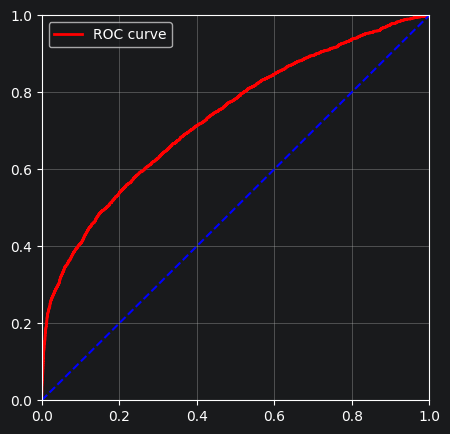

              precision    recall  f1-score   support

           0       0.93      0.80      0.86     22608
           1       0.26      0.54      0.35      2936

    accuracy                           0.77     25544
   macro avg       0.59      0.67      0.61     25544
weighted avg       0.85      0.77      0.80     25544



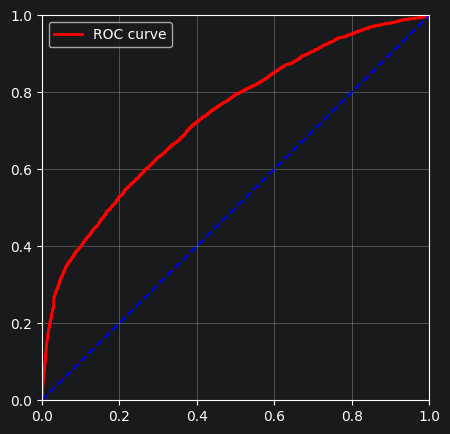

              precision    recall  f1-score   support

           0       0.91      0.87      0.89     22228
           1       0.33      0.44      0.38      3316

    accuracy                           0.81     25544
   macro avg       0.62      0.66      0.63     25544
weighted avg       0.84      0.81      0.82     25544



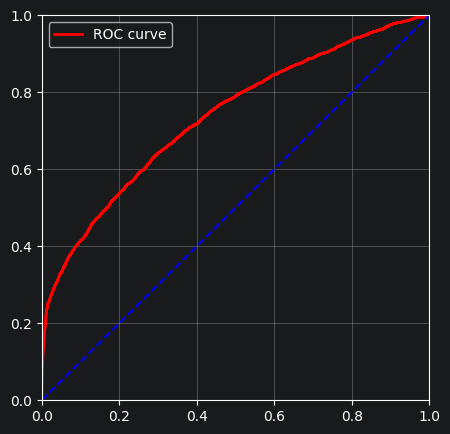

              precision    recall  f1-score   support

           0       0.92      0.87      0.89     19171
           1       0.33      0.46      0.39      2724

    accuracy                           0.82     21895
   macro avg       0.63      0.66      0.64     21895
weighted avg       0.85      0.82      0.83     21895



In [673]:
ginies_df = methods.evaluate_model(x_train, x_val, x_test, y_train, y_val, y_test, model_name='log_reg', ginies_df=ginies_df)

In [674]:
ginies_df

,model,train,val,test
0,log_reg,0.468207,0.47018,0.472411


#### **KNN**

In [675]:
importlib.reload(methods);

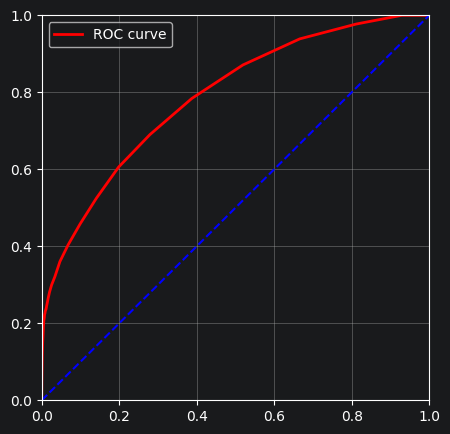

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     22608
           1       0.76      0.23      0.36      2936

    accuracy                           0.90     25544
   macro avg       0.83      0.61      0.65     25544
weighted avg       0.89      0.90      0.88     25544



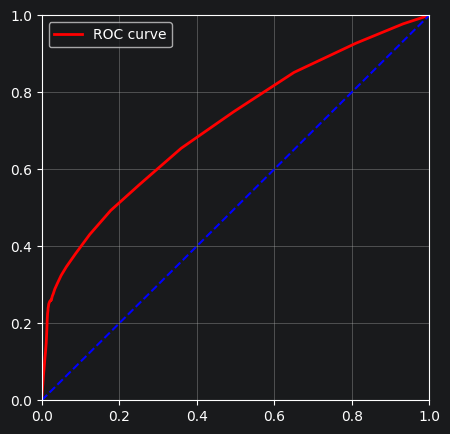

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     22228
           1       0.63      0.26      0.37      3316

    accuracy                           0.88     25544
   macro avg       0.77      0.62      0.65     25544
weighted avg       0.86      0.88      0.86     25544



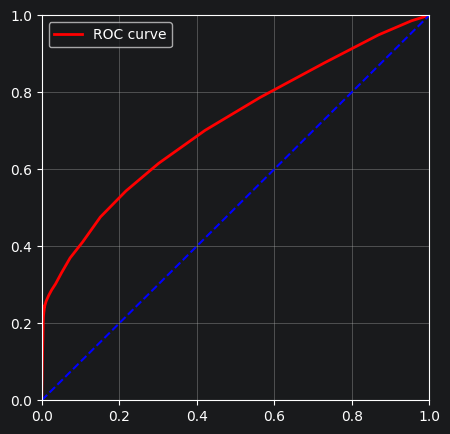

              precision    recall  f1-score   support

           0       0.90      0.99      0.95     19171
           1       0.83      0.24      0.38      2724

    accuracy                           0.90     21895
   macro avg       0.86      0.62      0.66     21895
weighted avg       0.89      0.90      0.87     21895



In [676]:
ginies_df = methods.evaluate_model(x_train, x_val, x_test, y_train, y_val, y_test, model_name='knn', ginies_df=ginies_df)

In [677]:
ginies_df

,model,train,val,test
0,log_reg,0.468207,0.470180,0.472411
1,knn,0.576000,0.426923,0.429810


#### **GaussanNB**

In [678]:
importlib.reload(methods);

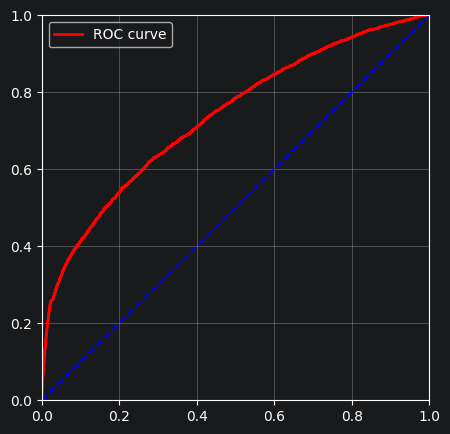

              precision    recall  f1-score   support

           0       0.91      0.96      0.94     22608
           1       0.51      0.29      0.37      2936

    accuracy                           0.89     25544
   macro avg       0.71      0.62      0.65     25544
weighted avg       0.87      0.89      0.87     25544



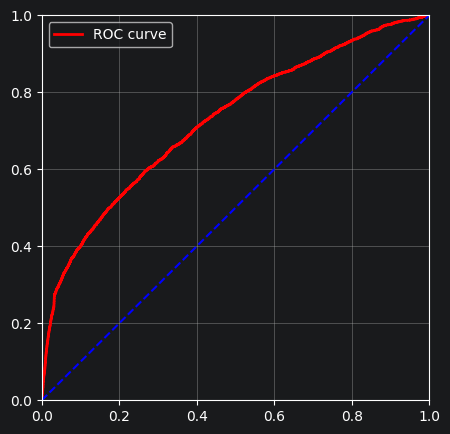

              precision    recall  f1-score   support

           0       0.90      0.96      0.93     22228
           1       0.52      0.29      0.37      3316

    accuracy                           0.87     25544
   macro avg       0.71      0.63      0.65     25544
weighted avg       0.85      0.87      0.86     25544



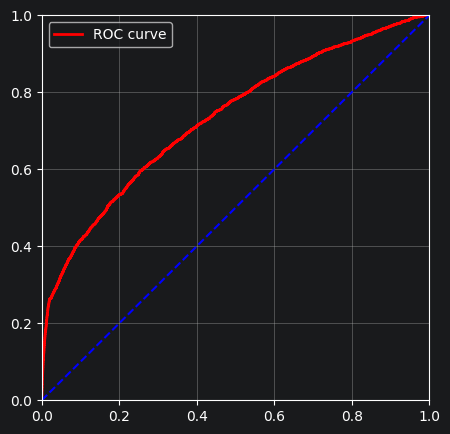

              precision    recall  f1-score   support

           0       0.91      0.97      0.93     19171
           1       0.54      0.29      0.38      2724

    accuracy                           0.88     21895
   macro avg       0.72      0.63      0.65     21895
weighted avg       0.86      0.88      0.86     21895



In [679]:
ginies_df = methods.evaluate_model(x_train, x_val, x_test, y_train, y_val, y_test, model_name='gaussian_nb', ginies_df=ginies_df)

In [680]:
ginies_df

,model,train,val,test
0,log_reg,0.468207,0.470180,0.472411
1,knn,0.576000,0.426923,0.429810
2,GaussianNB,0.470612,0.452636,0.465036


### **ROC AUC calculation Implementation**

In [681]:
#func roc_auc_curve in methods.py

### **My Logistic Regression**

**Log Reg SGD**

In [682]:
#in methods.py

In [683]:
importlib.reload(methods);

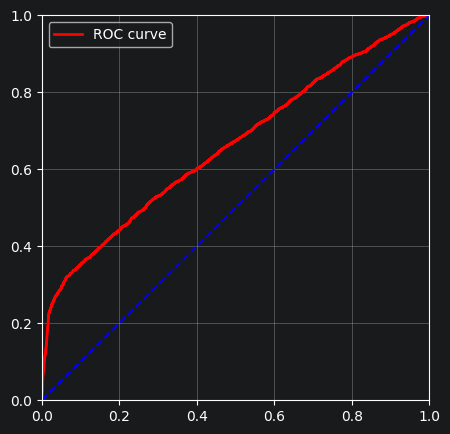

              precision    recall  f1-score   support

           0       0.92      0.54      0.68     22608
           1       0.15      0.65      0.25      2936

    accuracy                           0.55     25544
   macro avg       0.54      0.59      0.47     25544
weighted avg       0.83      0.55      0.63     25544



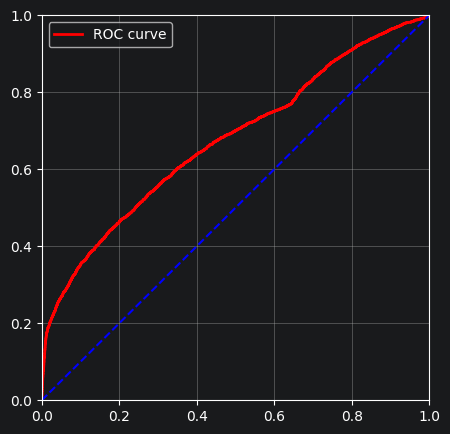

              precision    recall  f1-score   support

           0       0.92      0.57      0.71     22228
           1       0.19      0.66      0.29      3316

    accuracy                           0.58     25544
   macro avg       0.55      0.62      0.50     25544
weighted avg       0.82      0.58      0.65     25544



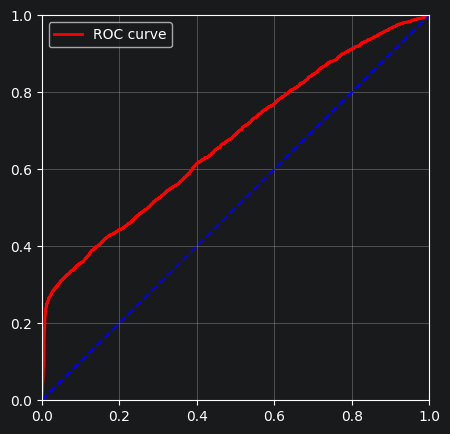

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     19171
           1       0.64      0.27      0.38      2724

    accuracy                           0.89     21895
   macro avg       0.77      0.62      0.66     21895
weighted avg       0.87      0.89      0.87     21895



In [684]:
ginies_df = methods.evaluate_model(x_train, x_val, x_test, y_train, y_val, y_test, model_name='my_log_reg', ginies_df=ginies_df, log_reg_approach='SGD')

In [685]:
ginies_df

,model,train,val,test
0,log_reg,0.468207,0.470180,0.472411
1,knn,0.576000,0.426923,0.429810
2,GaussianNB,0.470612,0.452636,0.465036
3,my_log_reg_SGD,0.321308,0.349455,0.347402


**Log Reg Classic Approach**

In [686]:
# in methods.py

In [687]:
importlib.reload(methods);

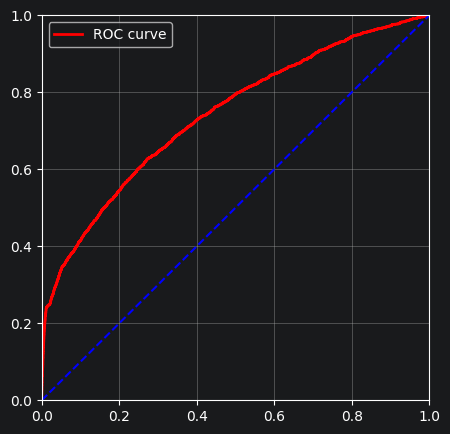

              precision    recall  f1-score   support

           0       0.93      0.79      0.85     22608
           1       0.26      0.56      0.35      2936

    accuracy                           0.76     25544
   macro avg       0.59      0.67      0.60     25544
weighted avg       0.85      0.76      0.80     25544



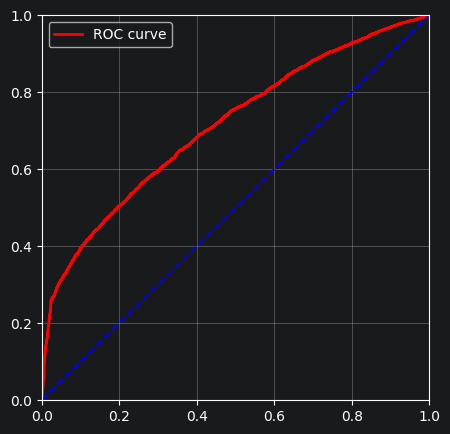

              precision    recall  f1-score   support

           0       0.92      0.80      0.85     22228
           1       0.27      0.51      0.35      3316

    accuracy                           0.76     25544
   macro avg       0.59      0.65      0.60     25544
weighted avg       0.83      0.76      0.79     25544



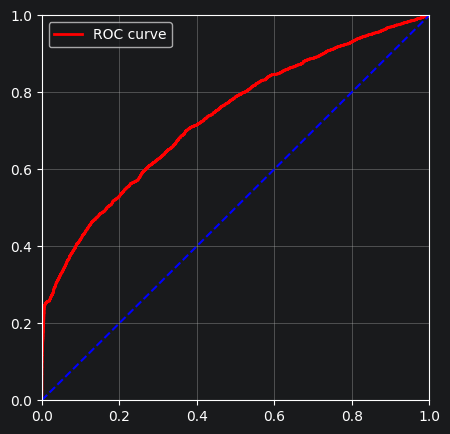

              precision    recall  f1-score   support

           0       0.93      0.74      0.82     19171
           1       0.24      0.59      0.35      2724

    accuracy                           0.72     21895
   macro avg       0.59      0.67      0.58     21895
weighted avg       0.84      0.72      0.76     21895



In [688]:
ginies_df = methods.evaluate_model(x_train, x_val, x_test, y_train, y_val, y_test, model_name='my_log_reg', ginies_df=ginies_df)

In [689]:
ginies_df

,model,train,val,test
0,log_reg,0.468207,0.470180,0.472411
1,knn,0.576000,0.426923,0.429810
2,GaussianNB,0.470612,0.452636,0.465036
3,my_log_reg_SGD,0.321308,0.349455,0.347402
4,my_log_reg_standard,0.480766,0.424765,0.466864


### **my KNN**

In [690]:
#in methods.py

In [691]:
importlib.reload(methods);

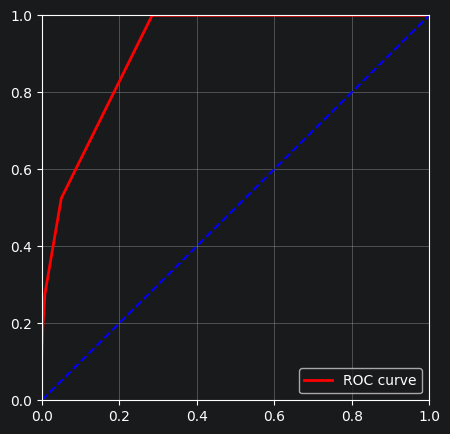

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     22608
           1       0.81      0.28      0.41      2936

    accuracy                           0.91     25544
   macro avg       0.86      0.63      0.68     25544
weighted avg       0.90      0.91      0.89     25544



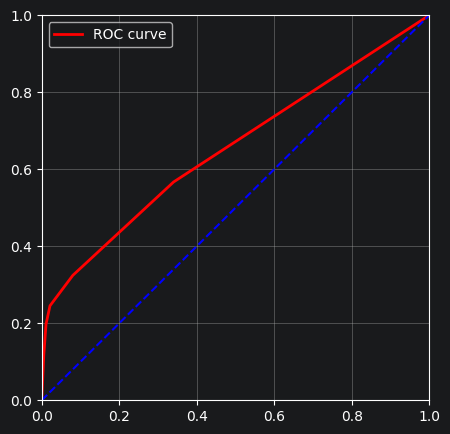

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     22228
           1       0.63      0.25      0.35      3316

    accuracy                           0.88     25544
   macro avg       0.76      0.61      0.64     25544
weighted avg       0.86      0.88      0.86     25544



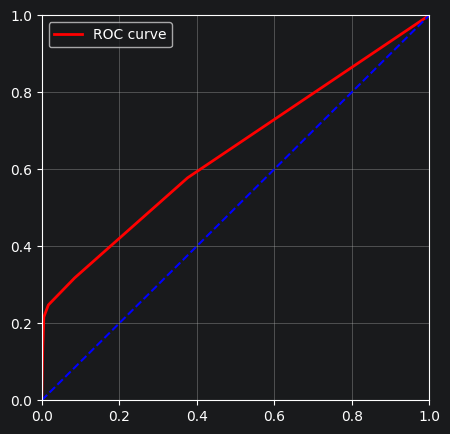

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     19171
           1       0.67      0.25      0.36      2724

    accuracy                           0.89     21895
   macro avg       0.79      0.62      0.65     21895
weighted avg       0.87      0.89      0.87     21895



In [692]:
ginies_df = methods.evaluate_model(x_train, x_val, x_test, y_train, y_val, y_test, model_name='my_knn', ginies_df=ginies_df)

In [693]:
ginies_df

,model,train,val,test
0,log_reg,0.468207,0.470180,0.472411
1,knn,0.576000,0.426923,0.429810
2,GaussianNB,0.470612,0.452636,0.465036
3,my_log_reg_SGD,0.321308,0.349455,0.347402
4,my_log_reg_standard,0.480766,0.424765,0.466864
5,my_knn,0.824725,0.306131,0.290076


### **my GaussianNB**

In [694]:
#in methods.py

In [695]:
importlib.reload(methods);

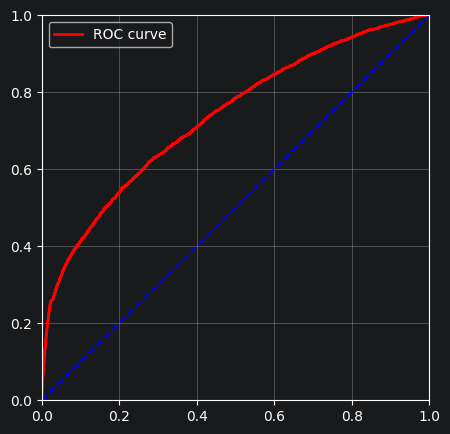

              precision    recall  f1-score   support

           0       0.91      0.96      0.94     22608
           1       0.51      0.29      0.37      2936

    accuracy                           0.89     25544
   macro avg       0.71      0.62      0.65     25544
weighted avg       0.87      0.89      0.87     25544



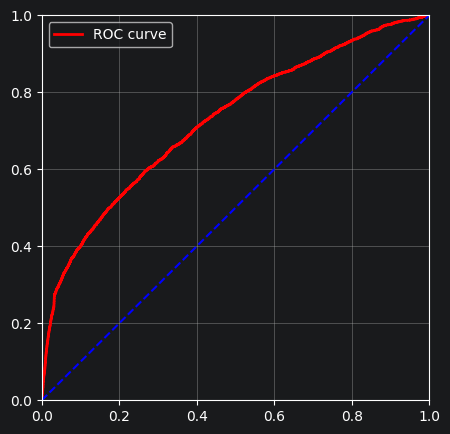

              precision    recall  f1-score   support

           0       0.90      0.96      0.93     22228
           1       0.52      0.29      0.37      3316

    accuracy                           0.87     25544
   macro avg       0.71      0.63      0.65     25544
weighted avg       0.85      0.87      0.86     25544



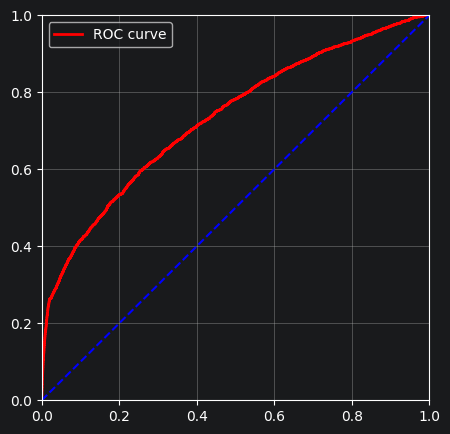

              precision    recall  f1-score   support

           0       0.91      0.97      0.93     19171
           1       0.54      0.29      0.38      2724

    accuracy                           0.88     21895
   macro avg       0.72      0.63      0.65     21895
weighted avg       0.86      0.88      0.86     21895



In [696]:
ginies_df = methods.evaluate_model(x_train, x_val, x_test, y_train, y_val, y_test, model_name='my_gaussian_nb', ginies_df=ginies_df)

In [697]:
ginies_df

,model,train,val,test
0,log_reg,0.468207,0.470180,0.472411
1,knn,0.576000,0.426923,0.429810
2,GaussianNB,0.470612,0.452636,0.465036
3,my_log_reg_SGD,0.321308,0.349455,0.347402
4,my_log_reg_standard,0.480766,0.424765,0.466864
5,my_knn,0.824725,0.306131,0.290076
6,my_gaussian_nb,0.470612,0.452636,0.465036


### **Non-linear features**

In [698]:
x_train['Make'] = make_train
x_val['Make'] = make_val
x_test['Make'] = make_test

In [987]:
df_tst['Make'] = make_df_tst

**Эти признаки у меня логарифмированы, поэтому их можно вычесть<br>
Мы получим log(A/B))**

In [699]:
# x_train["how deal's good"] = x_train['MMRAcquisitionAuctionAveragePrice'] - x_train['VehBCost']
# x_val["how deal's good"] = x_val['MMRAcquisitionAuctionAveragePrice'] - x_val['VehBCost']
# x_test["how deal's good"] = x_test['MMRAcquisitionAuctionAveragePrice'] - x_test['VehBCost']

**Считаем среднюю цену для каждой марки автомобиля**

In [700]:
x_train['Make'] = x_train['Make'].map(x_train.groupby('Make')['VehBCost'].mean())
x_val['Make'] = x_val['Make'].map(x_val.groupby('Make')['VehBCost'].mean())
x_test['Make'] = x_test['Make'].map(x_test.groupby('Make')['VehBCost'].mean())

In [1140]:
df_tst['Make'] = df_tst['Make'].map(df_tst.groupby('Make')['VehBCost'].mean())

**Насколько цена автомобиля отличается от средней цены для этой же марки**

In [701]:
x_train['Cost_vs_Make_Norm'] = (x_train['VehBCost'] / x_train['Make']) * 100
x_val['Cost_vs_Make_Norm'] = (x_val['VehBCost'] / x_val['Make']) * 100
x_test['Cost_vs_Make_Norm'] = (x_test['VehBCost'] / x_test['Make']) * 100

In [1141]:
df_tst['Cost_vs_Make_Norm'] = df_tst['VehBCost'] / df_tst['Make'] * 100

### **Refitting models**

#### **LogReg**

In [702]:
importlib.reload(methods);

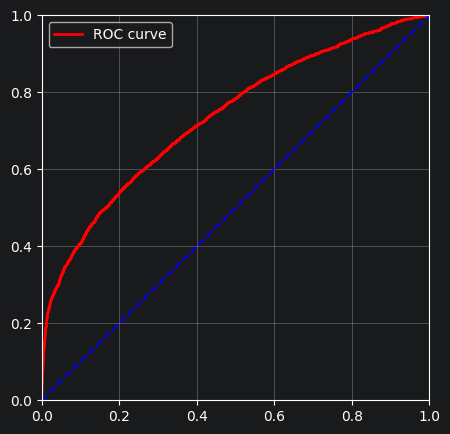

              precision    recall  f1-score   support

           0       0.93      0.80      0.86     22608
           1       0.26      0.54      0.35      2936

    accuracy                           0.77     25544
   macro avg       0.59      0.67      0.60     25544
weighted avg       0.85      0.77      0.80     25544



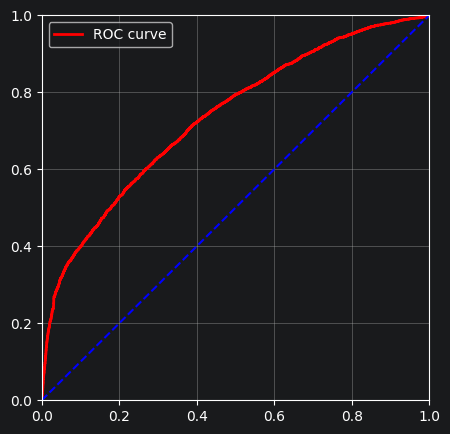

              precision    recall  f1-score   support

           0       0.91      0.87      0.89     22228
           1       0.33      0.44      0.38      3316

    accuracy                           0.81     25544
   macro avg       0.62      0.66      0.63     25544
weighted avg       0.84      0.81      0.82     25544



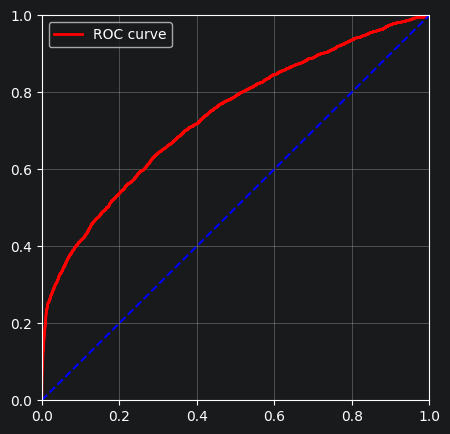

              precision    recall  f1-score   support

           0       0.92      0.87      0.89     19171
           1       0.33      0.46      0.39      2724

    accuracy                           0.82     21895
   macro avg       0.63      0.66      0.64     21895
weighted avg       0.85      0.82      0.83     21895



In [703]:
ginies_df, coefs = methods.evaluate_model(x_train, x_val, x_test, y_train, y_val, y_test, model_name='log_reg_enriched', ginies_df=ginies_df, return_coefs=True)

In [704]:
ginies_df

,model,train,val,test
0,log_reg,0.468207,0.470180,0.472411
1,knn,0.576000,0.426923,0.429810
2,GaussianNB,0.470612,0.452636,0.465036
3,my_log_reg_SGD,0.321308,0.349455,0.347402
4,my_log_reg_standard,0.480766,0.424765,0.466864
5,my_knn,0.824725,0.306131,0.290076
6,my_gaussian_nb,0.470612,0.452636,0.465036
7,log_reg_enriched,0.468216,0.470183,0.472420


#### **KNN**

In [705]:
importlib.reload(methods);

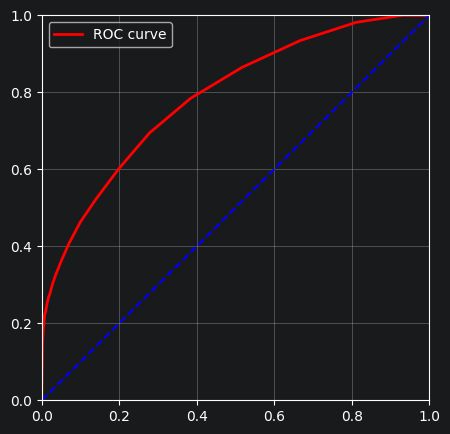

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     22608
           1       0.76      0.23      0.35      2936

    accuracy                           0.90     25544
   macro avg       0.83      0.61      0.65     25544
weighted avg       0.89      0.90      0.88     25544



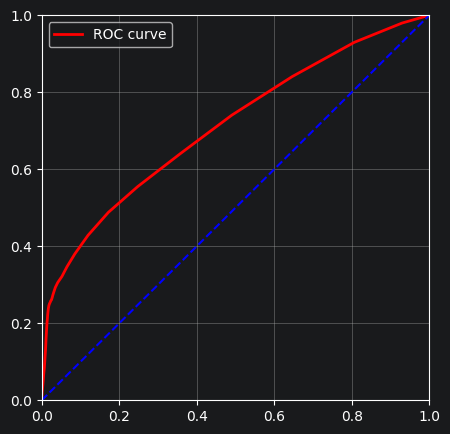

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     22228
           1       0.63      0.25      0.36      3316

    accuracy                           0.88     25544
   macro avg       0.77      0.62      0.65     25544
weighted avg       0.86      0.88      0.86     25544



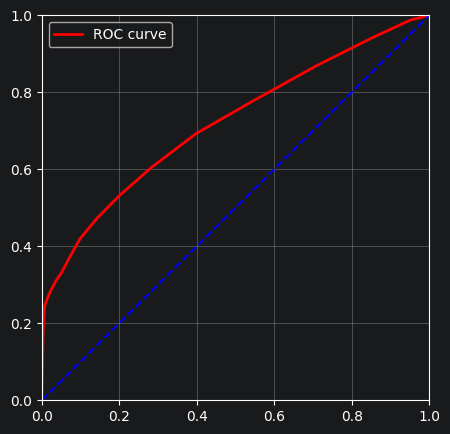

              precision    recall  f1-score   support

           0       0.90      0.99      0.95     19171
           1       0.83      0.24      0.37      2724

    accuracy                           0.90     21895
   macro avg       0.87      0.62      0.66     21895
weighted avg       0.89      0.90      0.87     21895



In [706]:
ginies_df = methods.evaluate_model(x_train, x_val, x_test, y_train, y_val, y_test, model_name='knn_enriched', ginies_df=ginies_df)

In [707]:
ginies_df

,model,train,val,test
0,log_reg,0.468207,0.470180,0.472411
1,knn,0.576000,0.426923,0.429810
2,GaussianNB,0.470612,0.452636,0.465036
3,my_log_reg_SGD,0.321308,0.349455,0.347402
4,my_log_reg_standard,0.480766,0.424765,0.466864
5,my_knn,0.824725,0.306131,0.290076
6,my_gaussian_nb,0.470612,0.452636,0.465036
7,log_reg_enriched,0.468216,0.470183,0.472420
8,knn_enriched,0.575029,0.421608,0.437104


#### **GaussianNB**

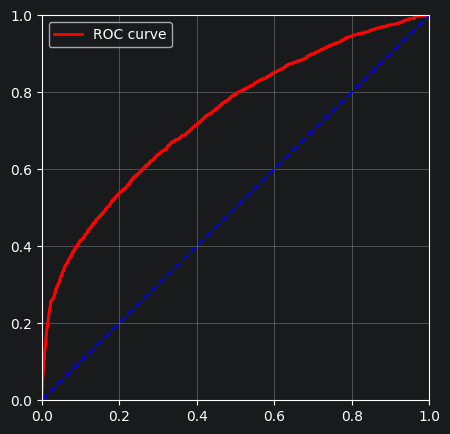

              precision    recall  f1-score   support

           0       0.92      0.95      0.93     22608
           1       0.46      0.32      0.38      2936

    accuracy                           0.88     25544
   macro avg       0.69      0.64      0.66     25544
weighted avg       0.86      0.88      0.87     25544



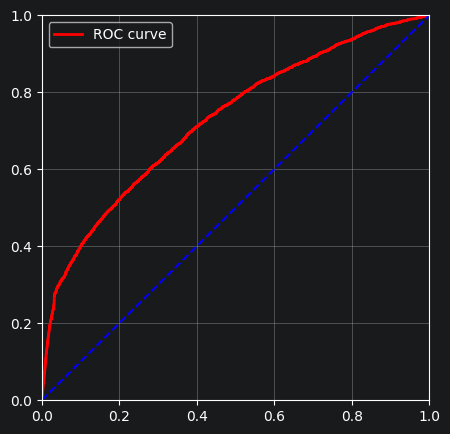

              precision    recall  f1-score   support

           0       0.90      0.95      0.93     22228
           1       0.48      0.31      0.38      3316

    accuracy                           0.87     25544
   macro avg       0.69      0.63      0.65     25544
weighted avg       0.85      0.87      0.85     25544



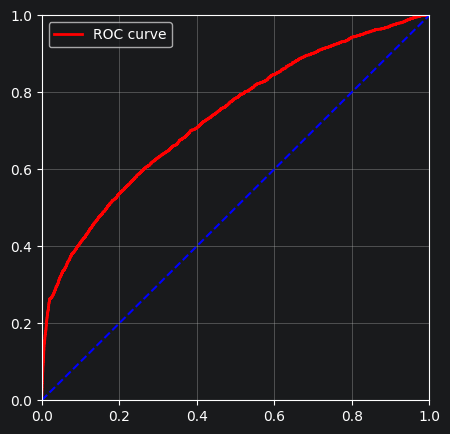

              precision    recall  f1-score   support

           0       0.91      0.95      0.93     19171
           1       0.49      0.32      0.39      2724

    accuracy                           0.87     21895
   macro avg       0.70      0.64      0.66     21895
weighted avg       0.86      0.87      0.86     21895



In [708]:
ginies_df = methods.evaluate_model(x_train, x_val, x_test, y_train, y_val, y_test, model_name='gaussian_nb_enriched', ginies_df=ginies_df)

In [712]:
ginies_df.sort_values(by=['test', 'val'], ascending=False)

,model,train,val,test
7,log_reg_enriched,0.468216,0.470183,0.472420
0,log_reg,0.468207,0.470180,0.472411
9,gaussian_nb_enriched,0.474297,0.453609,0.468162
4,my_log_reg_standard,0.480766,0.424765,0.466864
2,GaussianNB,0.470612,0.452636,0.465036
6,my_gaussian_nb,0.470612,0.452636,0.465036
8,knn_enriched,0.575029,0.421608,0.437104
1,knn,0.576000,0.426923,0.429810
3,my_log_reg_SGD,0.321308,0.349455,0.347402
5,my_knn,0.824725,0.306131,0.290076


**Посмотрим, что еще можно сделать для того, чтобы увеличить gini-score для логистической регрессии**

In [738]:
coefs_abs = np.abs(coefs[coefs != 0])
indices = np.argsort(coefs_abs)[::-1]
coefs_abs = coefs_abs[indices]
cols = np.asarray(x_train.columns[indices])
np.column_stack([cols, coefs_abs])

array([['VehBCost', 0.41925801818652325],
       ['VehYear', 0.3172452304219688],
       ['WheelTypeID', 0.12766462344524207],
       ['VehOdo', 0.04943536584800711],
       ['MMRAcquisitionAuctionAveragePrice', 0.03657590765354381]],
      dtype=object)

**Создание нелинейных признаков для логистической регрессии**

In [1079]:
poly = PolynomialFeatures(degree=2, include_bias=False)
x_train_poly = pd.DataFrame(poly.fit_transform(x_train[cols]), columns=poly.get_feature_names_out()).set_index(x_train.index)
x_val_poly = pd.DataFrame(poly.fit_transform(x_val[cols]), columns=poly.get_feature_names_out()).set_index(x_val.index)
x_test_poly = pd.DataFrame(poly.transform(x_test[cols]), columns=poly.get_feature_names_out()).set_index(x_test.index)

In [1142]:
df_tst_poly = pd.DataFrame(poly.transform(df_tst[cols]), columns=poly.get_feature_names_out()).set_index(df_tst.index)

In [1081]:
x_train_poly = pd.concat([x_train_poly, x_train.drop(columns=cols)], axis=1)
x_val_poly = pd.concat([x_val_poly, x_val.drop(columns=cols)], axis=1)
x_test_poly = pd.concat([x_test_poly, x_test.drop(columns=cols)], axis=1)

In [1143]:
df_tst_poly = pd.concat([df_tst_poly, df_tst.drop(columns=cols)], axis=1)

In [1144]:
x_train_poly

,VehBCost,VehYear,MMRAcquisitionAuctionAveragePrice,WheelTypeID,VehOdo,VehBCost^2,VehBCost VehYear,VehBCost MMRAcquisitionAuctionAveragePrice,VehBCost WheelTypeID,VehBCost VehOdo,...,Model,Trim,SubModel,Color,WheelType,Nationality,Size,TopThreeAmericanName,VNST,Cost_vs_Make_Norm
32367,8.820404,7.604894,8.890411,1.098612,11.271389,17.640513,16.424653,17.710529,9.513477,20.091632,...,4.644391,8.475746,5.686975,8.193953,9.319733,10.008568,6.576470,9.050406,7.648263,4.670434
32384,8.725994,7.603898,8.391630,0.693147,10.536805,17.451664,16.329231,17.117235,8.725994,19.262611,...,5.774552,5.627621,3.912023,8.565602,9.485469,10.008568,7.854381,8.483843,7.648263,4.628963
32385,8.354910,7.603399,8.038835,1.098612,11.179981,16.709349,15.957575,16.393186,9.047939,19.534641,...,5.579730,8.188967,7.314553,8.565602,9.319733,10.008568,9.174299,9.050406,7.648263,4.187808
32386,9.009570,7.604396,9.051462,0.693147,11.148463,18.018895,16.613345,18.060792,9.009570,20.157896,...,4.043051,8.051022,5.204007,8.395252,9.485469,10.008568,8.033658,9.089302,7.648263,4.842674
32387,8.497195,7.603399,8.037543,0.693147,11.105423,16.993981,16.099891,16.534211,8.497195,19.602399,...,6.912743,5.627621,4.110874,7.585789,9.485469,10.008568,9.174299,8.483843,7.648263,4.402629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53562,8.922792,7.605392,9.091332,1.098612,10.882528,17.845317,16.527553,18.013877,9.615872,19.805167,...,5.971262,6.741701,5.752573,8.565602,9.319733,10.008568,9.174299,9.050406,6.768493,4.771924
40315,8.747670,7.603399,8.249314,0.693147,10.950403,17.495022,16.350411,16.996563,8.747670,19.697896,...,5.164786,4.060443,3.737670,6.622736,9.485469,10.008568,9.174299,9.089302,8.192017,4.803006
40316,8.506334,7.603898,8.037543,0.693147,10.904211,17.012265,16.109532,16.543352,8.506334,19.410325,...,4.330733,8.051022,8.553332,8.565602,9.485469,10.008568,7.734996,9.089302,8.192017,4.344505
66240,8.244334,7.602401,7.873978,0.693147,11.265733,16.488143,15.845973,16.117669,8.244334,19.509791,...,4.477337,8.188967,7.314553,7.585789,9.485469,10.008568,7.734996,8.483843,7.844241,4.153228


In [1145]:
df_tst_poly

,VehBCost,VehYear,MMRAcquisitionAuctionAveragePrice,WheelTypeID,VehOdo,VehBCost^2,VehBCost VehYear,VehBCost MMRAcquisitionAuctionAveragePrice,VehBCost WheelTypeID,VehBCost VehOdo,...,Model,Trim,SubModel,Color,WheelType,Nationality,Size,TopThreeAmericanName,VNST,Cost_vs_Make_Norm
0,6500.0,2005.0,5032.0,1.0,85377.0,42250000.0,13032500.0,32708000.0,6500.0,554950500.0,...,2.0,4796.0,5183.0,5247.0,13166,22215.0,3123.0,8859.0,1081.0,96.661955
1,6300.0,2005.0,4502.0,1.0,61873.0,39690000.0,12631500.0,28362600.0,6300.0,389799900.0,...,1.0,3136.0,1330.0,5247.0,13166,22215.0,9645.0,8859.0,1081.0,92.097426
2,9700.0,2006.0,10244.0,1.0,69283.0,94090000.0,19458200.0,99366800.0,9700.0,672045100.0,...,2.0,46.0,19.0,5247.0,13166,22215.0,3082.0,8521.0,1081.0,134.910617
3,4150.0,2002.0,2558.0,1.0,87889.0,17222500.0,8308300.0,10615700.0,4150.0,364739350.0,...,0.0,44.0,44.0,1969.0,13166,22215.0,9645.0,8859.0,1081.0,73.429723
4,4100.0,2007.0,5013.0,1.0,73432.0,16810000.0,8228700.0,20553300.0,4100.0,301071200.0,...,0.0,111.0,18.0,3618.0,963,2398.0,2286.0,3329.0,1081.0,67.797247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48702,7955.0,2005.0,5358.0,1.0,88645.0,63282025.0,15949775.0,42622890.0,7955.0,705170975.0,...,2.0,381.0,205.0,2414.0,13166,22215.0,3123.0,4835.0,3611.0,123.524519
48703,7035.0,2007.0,6849.0,2.0,81862.0,49491225.0,14119245.0,48182715.0,14070.0,575899170.0,...,1.0,17.0,25.0,1248.0,11155,900.0,2286.0,3329.0,3611.0,85.848682
48704,6335.0,2006.0,4662.0,2.0,82451.0,40132225.0,12708010.0,29533770.0,12670.0,522327085.0,...,1.0,621.0,265.0,2414.0,11155,2398.0,9645.0,3329.0,3611.0,103.194808
48705,8055.0,2005.0,5953.0,1.0,75760.0,64883025.0,16150275.0,47951415.0,8055.0,610246800.0,...,3.0,34.0,174.0,5247.0,13166,2398.0,9645.0,3329.0,3611.0,113.810175


In [1085]:
# x_train_poly.drop(columns=['WheelTypeID', 'WheelTypeID^2'], inplace=True)
# x_val_poly.drop(columns=['WheelTypeID', 'WheelTypeID^2'], inplace=True)
# x_test_poly.drop(columns=['WheelTypeID', 'WheelTypeID^2'], inplace=True)

In [1086]:
x_train_poly = np.log1p(x_train_poly)
x_val_poly = np.log1p(x_val_poly)
x_test_poly = np.log1p(x_test_poly)

In [1146]:
df_tst_poly = np.log1p(df_tst_poly)

In [1088]:
importlib.reload(methods);

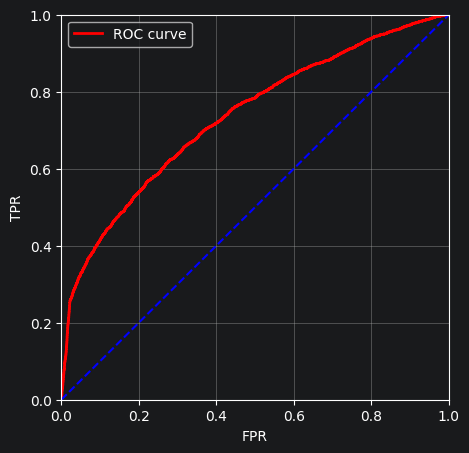

              precision    recall  f1-score   support

           0       0.93      0.79      0.86     22608
           1       0.25      0.55      0.35      2936

    accuracy                           0.76     25544
   macro avg       0.59      0.67      0.60     25544
weighted avg       0.85      0.76      0.80     25544



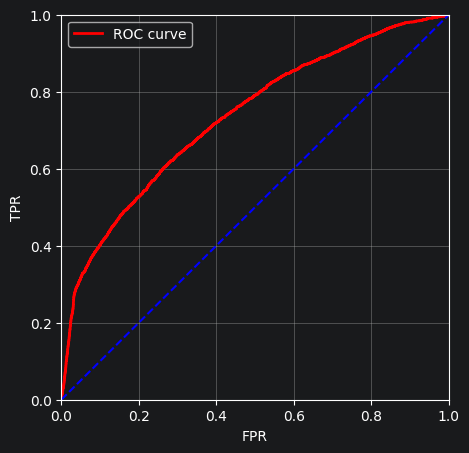

              precision    recall  f1-score   support

           0       0.91      0.87      0.89     22228
           1       0.34      0.45      0.38      3316

    accuracy                           0.81     25544
   macro avg       0.62      0.66      0.64     25544
weighted avg       0.84      0.81      0.82     25544



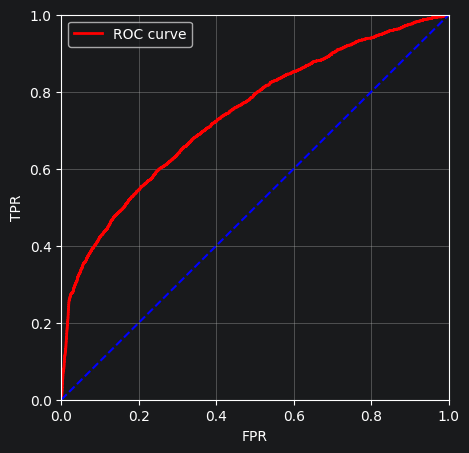

              precision    recall  f1-score   support

           0       0.92      0.88      0.90     19171
           1       0.34      0.46      0.39      2724

    accuracy                           0.82     21895
   macro avg       0.63      0.67      0.64     21895
weighted avg       0.85      0.82      0.83     21895



In [1089]:
import warnings
warnings.filterwarnings('ignore')

ginies_df, coefs, estimator = methods.evaluate_model(x_train_poly, x_val_poly, x_test_poly, y_train, y_val, y_test, model_name='log_reg_enriched_2', ginies_df=ginies_df, return_coefs=True, return_estimator=True)

In [1090]:
ginies_df = ginies_df.sort_values(by=['test', 'val'], ascending=False)

In [1091]:
ginies_df

,model,train,val,test
10,log_reg_enriched_2,0.468529,0.468099,0.479105
7,log_reg_enriched,0.468216,0.470183,0.472420
0,log_reg,0.468207,0.470180,0.472411
9,gaussian_nb_enriched,0.474297,0.453609,0.468162
4,my_log_reg_standard,0.480766,0.424765,0.466864
2,GaussianNB,0.470612,0.452636,0.465036
6,my_gaussian_nb,0.470612,0.452636,0.465036
8,knn_enriched,0.575029,0.421608,0.437104
1,knn,0.576000,0.426923,0.429810
3,my_log_reg_SGD,0.321308,0.349455,0.347402


In [1092]:
ginies_df_done = ginies_df.copy()

In [1093]:
best_model = estimator
best_model.get_params()

{'C': 0.001,
 'class_weight': 'balanced',
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 1,
 'max_iter': 4000,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'saga',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}


#### **Самое большое влияние оказал параметр C (сила регуляризации) в комбинации с L1-регуляризацией.**<br>

**Низкое значение C=0.001 c L1-регуляризацией позволило жестко отфильтровать неважные признаки и помогло модели не переобучиться. Показатели Gini на train, val и test практически одинаковые. Если бы модель переобучилась, метрика на train среди остальных выборок была бы сильно завышена (как например у my_knn). Так же важную роль в стабильности модели сыграл параметр class_weight='balanced', который уровнял классы между собой при дисбалансе**

### **Implement calculation of Recall, Precision, F1 score and AUC PR metrics**

In [1094]:
#in methods.py

### **Compare your algorithms on the test dataset using AUC PR metric**

In [1100]:
importlib.reload(methods);

In [1096]:
auc_pr = pd.Series(index=['Log_Reg', 'KNN', 'GaussianNB'])

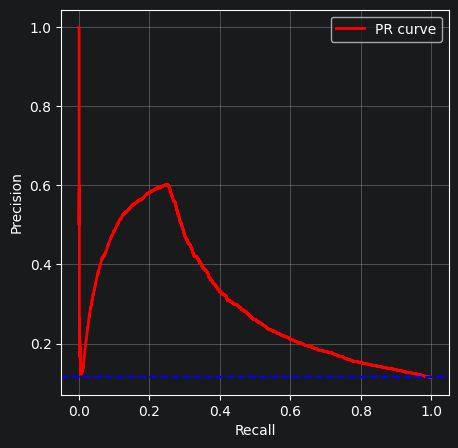

In [1098]:
auc_pr['Log_Reg'] = methods.auc_pr_comparison(x_train_poly, y_train, best_model)

In [1101]:
knn = methods.evaluate_model(x_train_poly, x_val_poly, x_test_poly, y_train, y_val, y_test, model_name='knn', return_estimator=True)

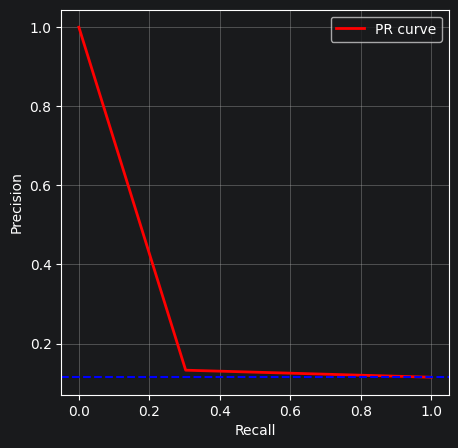

In [1103]:
auc_pr['KNN'] = methods.auc_pr_comparison(x_train_poly, y_train, knn)

In [1104]:
gaussianNB = methods.evaluate_model(x_train_poly, x_val_poly, x_test_poly, y_train, y_val, y_test, model_name='gaussian_nb', return_model=True)

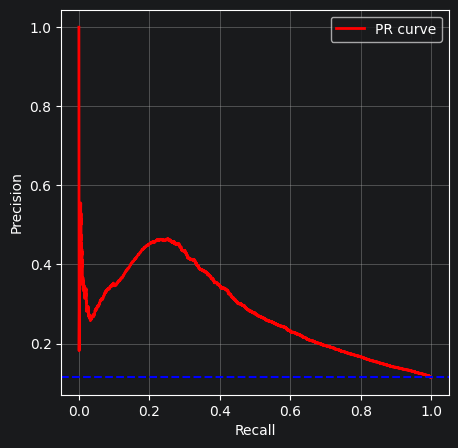

In [1105]:
auc_pr['GaussianNB'] = methods.auc_pr_comparison(x_train_poly, y_train, gaussianNB)

In [1106]:
auc_pr.sort_values(ascending=False)

Log_Reg       0.300786
GaussianNB    0.280189
KNN           0.257974
dtype: float64

#### **Which hard label metric do you prefer for the task of detecting "lemon" cars?**<br>
**Однозначно recall, так как нам нужно минимизировать ошибку второго рода: модель оценивает хороший объект как плохой (машину с дефектами как нормальную), так как дилер может потерять деньги на этой покупке, сделка для него окажется невыгодной**